# Linear Regression with NumPy
Two approaches: OLS closed-form and Batch Gradient Descent — no sklearn.

## 1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

raw = fetch_california_housing(as_frame=True)
df  = raw.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Convert to NumPy & Split 80/20

In [2]:
from sklearn.model_selection import train_test_split as sk_split

X_all = df[raw.feature_names].values
y_all = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = sk_split(
    X_all, y_all, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 16,512  |  Test: 4,128


## 3. Add Bias Column

In [3]:
X_train_b = np.column_stack([np.ones(len(X_train)), X_train])
X_test_b  = np.column_stack([np.ones(len(X_test)),  X_test])
print("Design matrix shape:", X_train_b.shape)

Design matrix shape: (16512, 9)


## 4. Shared Metrics Function

In [4]:
def metrics(y_true, y_pred, label):
    resid  = y_true - y_pred
    mse    = np.mean(resid ** 2)
    rmse   = np.sqrt(mse)
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2     = 1 - ss_res / ss_tot
    print(f"{label:<6} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

---
# Approach A: OLS Closed-Form
$$\beta = (X^T X)^{-1} X^T y$$

Direct analytical solution. Fast and exact, but O(p³) inversion cost makes it
impractical when the feature count is very large.

In [5]:
beta_ols = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

coef_names = ["bias"] + list(raw.feature_names)
pd.DataFrame({"Feature": coef_names, "Coefficient": beta_ols}).set_index("Feature")

,Coefficient
Feature,
bias,-37.023278
MedInc,0.448675
HouseAge,0.009724
AveRooms,-0.123323
AveBedrms,0.783145
Population,-0.000002
AveOccup,-0.003526
Latitude,-0.419792
Longitude,-0.433708


In [6]:
print("--- OLS ---")
metrics(y_train, X_train_b @ beta_ols, "Train")
metrics(y_test,  X_test_b  @ beta_ols, "Test")

--- OLS ---
Train  | MSE: 0.5179 | RMSE: 0.7197 | R²: 0.6126
Test   | MSE: 0.5559 | RMSE: 0.7456 | R²: 0.5758


---
# Approach B: Batch Gradient Descent

Iteratively nudges β in the direction that reduces MSE the most.

**Loss (MSE):**
$$J(\beta) = \frac{1}{n} \|X\beta - y\|^2$$

**Gradient:**
$$\nabla_{\beta} J = \frac{2}{n} X^T (X\beta - y)$$

**Update rule (one step):**
$$\beta \leftarrow \beta - \alpha \cdot \nabla_{\beta} J$$

- Uses **all** training samples per update — this is what makes it "batch"
- Requires **feature scaling** — without it, features with large ranges dominate the gradient
- Key hyperparameters: learning rate $\alpha$, number of epochs

## 5. Feature Scaling (Standardisation)

Fit scaler on **train only** to avoid data leakage. Apply the same transform to test.

In [7]:
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

X_train_sc = (X_train - X_mean) / X_std
X_test_sc  = (X_test  - X_mean) / X_std

# Add bias AFTER scaling — the intercept column must always be 1
X_train_scb = np.column_stack([np.ones(len(X_train_sc)), X_train_sc])
X_test_scb  = np.column_stack([np.ones(len(X_test_sc)),  X_test_sc])

## 6. Gradient Descent Training Loop

In [8]:
def gradient_descent(X, y, lr=0.1, epochs=1000, log_every=100):
    """
    Batch Gradient Descent for Linear Regression.

    Forward pass:   y_hat    = X @ beta
    Loss (MSE):     J        = mean((y_hat - y)^2)
    Gradient:       dJ/dbeta = (2/n) * X.T @ (y_hat - y)
    Update:         beta    -= lr * gradient
    """
    n, p   = X.shape
    beta   = np.zeros(p)      # start at origin
    losses = []

    for epoch in range(1, epochs + 1):
        residual = X @ beta - y                  # (n,)
        loss     = np.mean(residual ** 2)        # scalar MSE
        gradient = (2 / n) * X.T @ residual     # (p,)
        beta    -= lr * gradient                 # in-place update
        losses.append(loss)

        if epoch % log_every == 0 or epoch == 1:
            print(f"Epoch {epoch:>5} | MSE: {loss:.6f}")

    return beta, losses


beta_gd, loss_history = gradient_descent(
    X_train_scb, y_train, lr=0.1, epochs=1000, log_every=100
)

Epoch     1 | MSE: 5.629742
Epoch   100 | MSE: 0.524659
Epoch   200 | MSE: 0.518397
Epoch   300 | MSE: 0.517983
Epoch   400 | MSE: 0.517940
Epoch   500 | MSE: 0.517934
Epoch   600 | MSE: 0.517933
Epoch   700 | MSE: 0.517933
Epoch   800 | MSE: 0.517933
Epoch   900 | MSE: 0.517933
Epoch  1000 | MSE: 0.517933


## 7. Loss Curve

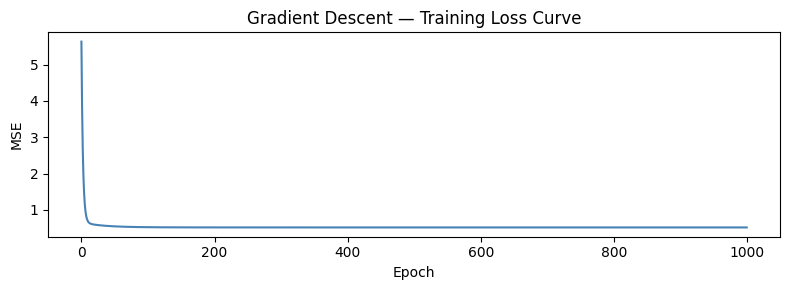

In [9]:
plt.figure(figsize=(8, 3))
plt.plot(loss_history, color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Gradient Descent — Training Loss Curve")
plt.tight_layout()
plt.show()

## 8. Learned Coefficients (Gradient Descent)

In [10]:
pd.DataFrame({
    "Feature":     ["bias"] + list(raw.feature_names),
    "Coefficient": beta_gd
}).set_index("Feature")

,Coefficient
Feature,
bias,2.071947
MedInc,0.854393
HouseAge,0.122548
AveRooms,-0.294427
AveBedrms,0.339273
Population,-0.002307
AveOccup,-0.040830
Latitude,-0.896907
Longitude,-0.869821


## 9. Evaluate (Gradient Descent)

In [11]:
print("--- Gradient Descent ---")
metrics(y_train, X_train_scb @ beta_gd, "Train")
metrics(y_test,  X_test_scb  @ beta_gd, "Test")

--- Gradient Descent ---
Train  | MSE: 0.5179 | RMSE: 0.7197 | R²: 0.6126
Test   | MSE: 0.5559 | RMSE: 0.7456 | R²: 0.5758


---
## 10. OLS vs Gradient Descent — Side-by-Side

> Coefficients differ because GD operates on standardised features.
> Both minimise the same loss — final MSE / R² should be nearly identical.

In [12]:
print("=== OLS (unscaled) ===")
metrics(y_train, X_train_b   @ beta_ols, "Train")
metrics(y_test,  X_test_b    @ beta_ols, "Test")

print("\n=== Gradient Descent (standardised) ===")
metrics(y_train, X_train_scb @ beta_gd,  "Train")
metrics(y_test,  X_test_scb  @ beta_gd,  "Test")

=== OLS (unscaled) ===
Train  | MSE: 0.5179 | RMSE: 0.7197 | R²: 0.6126
Test   | MSE: 0.5559 | RMSE: 0.7456 | R²: 0.5758

=== Gradient Descent (standardised) ===
Train  | MSE: 0.5179 | RMSE: 0.7197 | R²: 0.6126
Test   | MSE: 0.5559 | RMSE: 0.7456 | R²: 0.5758


---
## Bonus: Effect of Learning Rate

Too large → loss diverges or oscillates. Too small → convergence is painfully slow.
Plotting several values on the same axis builds intuition for tuning.

Epoch     1 | MSE: 5.629742
Epoch     1 | MSE: 5.629742
Epoch     1 | MSE: 5.629742
Epoch     1 | MSE: 5.629742


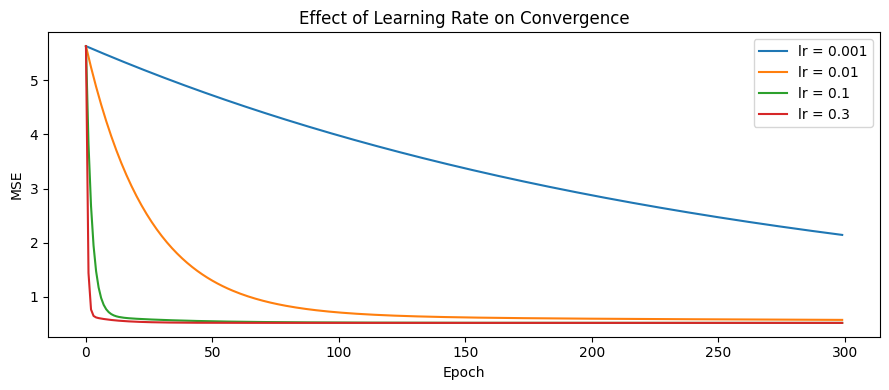

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))

for lr in [0.001, 0.01, 0.1, 0.3]:
    _, losses = gradient_descent(X_train_scb, y_train, lr=lr, epochs=300, log_every=9999)
    ax.plot(losses, label=f"lr = {lr}")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Effect of Learning Rate on Convergence")
ax.legend()
plt.tight_layout()
plt.show()

## Save Model to `../Models/`

In [14]:
import os
save_path = '../Models/lr_numpy.npz'
np.savez_compressed(
    save_path,
    feature_names = np.array(raw.feature_names),
    beta_ols      = beta_ols,          # (9,)  bias + 8 features, unscaled
    beta_gd       = beta_gd,           # (9,)  bias + 8 features, z-score scaled
    x_mean        = X_mean,            # (8,)  feature means from train set
    x_std         = X_std              # (8,)  feature stds from train set
)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/lr_numpy.npz  (1.3 KB)
